In [1]:
%load_ext autoreload
%autoreload 2
import cooler
import pandas as pd
import sys
sys.path.append("./code")

In [2]:
%load_ext autoreload
%autoreload
import scanpy as sc
import sys

sys.path.append('./code2')

from hic_zscore_functions import make_obs_exp_intra
from aux_functions import *
from plotting_functions import *

sc.settings.set_figure_params(dpi=80, color_map='coolwarm', frameon=True)
plt.rcParams.update({'font.size': 12})
plt.rcParams.update({"axes.grid.axis" : 'both'})
plt.rcParams.update({"axes.grid" : True})

plt.rcParams.update({
    'axes.labelsize': 14,       # x and y labels' font size
    'xtick.labelsize': 8,      # x tick labels' font size
    'ytick.labelsize': 8,      # y tick labels' font size
    'axes.titlesize': 14,        # Axes title font size
    'patch.linewidth' : .35,
    'lines.linewidth' : .5,
    'legend.fontsize': 6,      # Legend font size
})
plt.rcParams['pdf.fonttype'] = 42

plt.rcParams.update({
    'axes.labelsize': 8,       # x and y labels' font size
    'xtick.labelsize': 6,      # x tick labels' font size
    'ytick.labelsize': 6,      # y tick labels' font size
    'axes.titlesize': 10,        # Axes title font size
    'patch.linewidth' : .35,
    'lines.linewidth' : .5,
    'xtick.major.pad' : 2,
    'ytick.major.pad' : 2,

})
plt.rcParams['axes.linewidth'] = .25
plt.rcParams['xtick.major.width'] = .25
plt.rcParams['ytick.major.width'] = .25
plt.rcParams['ytick.major.size'] = 2
plt.rcParams['xtick.major.size'] = 2
plt.rcParams['grid.linewidth'] = .25

plt.rcParams['axes.facecolor'] = 'none' # Or any suitable colour...
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['savefig.facecolor'] = 'none'

plt.rcParams['axes.facecolor'] = 'none' # Or any suitable colour...
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'white'
plt.rcParams['savefig.facecolor'] = 'none'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
def get_motif_fc(motif_df, idx_x, idx_y, freq=.15):
    x = motif_df.loc[idx_x].mean()
    y = motif_df.loc[idx_y].mean()
    idx = (x > freq) | (y > freq)
    return np.log2(x[idx]/y[idx]).sort_values()


In [4]:
res = 12800
plt.rcParams['axes.axisbelow'] = True

cool_nc18 = cooler.Cooler(f'./cools/nc1-8_1_1+1_2+2_1+2_2.base_resolution=100.mcool::/resolutions/{res}')
cool_nc14 = cooler.Cooler(f'./cools/nc14_1_1+1_2+2_1+2_2.base_resolution=100.mcool::/resolutions/{res}')
cool_s10 = cooler.Cooler(f'./cools/s10-12_1_1+1_2+2_1+2_2.base_resolution=100.mcool::/resolutions/{res}')

### LOAD ALL CSES

In [14]:
from config import load_cses
from config import rgb_to_cluster, cluster_to_rgb
all_cses = load_cses()

In [6]:
atac_summit_motifs = pd.read_csv('/Genomics/argo/users/gdolsten/pritlab/jupys/tregs/rudensky_scrna/prelim-analysis/meme/fimo_output/dm6_atac_atlas.bed',
           sep='\t')
atac_summit_motifs['chr'] = atac_summit_motifs['chr'].str.replace("CHR", "")

In [8]:
boundaries_s10 = pd.read_csv('loop_and_boundary_output/browser_tracks/s10-12_1_1+1_2+2_1+2_2.boundaries_and_both_with_cluster_colors.scores=plain.bed', sep='\t', header=None)
boundaries_s10.index = df_to_index(boundaries_s10.iloc[:, :3])

boundaries_nc14 = pd.read_csv('loop_and_boundary_output/browser_tracks/nc14_1_1+1_2+2_1+2_2.boundaries_and_both_with_cluster_colors.scores=plain.bed', sep='\t', header=None)
boundaries_nc14.index = df_to_index(boundaries_nc14.iloc[:, :3])

boundaries_nc18 = pd.read_csv('loop_and_boundary_output/browser_tracks/nc1-8_1_1+1_2+2_1+2_2.boundaries_and_both_with_cluster_colors.scores=plain.bed', sep='\t', header=None)
boundaries_nc18.index = df_to_index(boundaries_nc18.iloc[:, :3])

In [9]:
boundary_motifs = pd.read_csv('./intermediate_files/cses_with_motif.csv', sep='\t', index_col = 0)

In [11]:
boundaryStrengths = pd.concat([boundaries_s10[4], boundaries_nc14[4], boundaries_nc18[4],], axis=1)
boundaryStrengths.columns = ['s10', 'nc14', 'nc18']

In [13]:
import matplotlib.colors as mcolors
import numpy as np

# Define a function to create a modified coolwarm colormap
def modified_coolwarm():
    # Get the coolwarm colormap
    coolwarm = plt.cm.get_cmap('coolwarm', 256)
    
    # Convert the colormap into a numpy array for manipulation
    coolwarm_colors = coolwarm(np.linspace(0, 1, 256))
    
    # Adjust the middle colors to a dark gray
    for i in range(120, 136):  # Narrow band near the center
        coolwarm_colors[i] = [0.3, 0.3, 0.3, 1.0]  # Dark gray in RGB
    
    # Create a new colormap from the modified colors
    return mcolors.ListedColormap(coolwarm_colors)

# Generate the modified colormap
mod_coolwarm = modified_coolwarm()


/tmp/ipykernel_2986917/3352665124.py:7: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  coolwarm = plt.cm.get_cmap('coolwarm', 256)


/Genomics/argo/users/gdolsten/.conda/envs/mamba/envs/new_3dgenome/lib/python3.10/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Genomics/argo/users/gdolsten/.conda/envs/mamba/envs/new_3dgenome/lib/python3.10/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


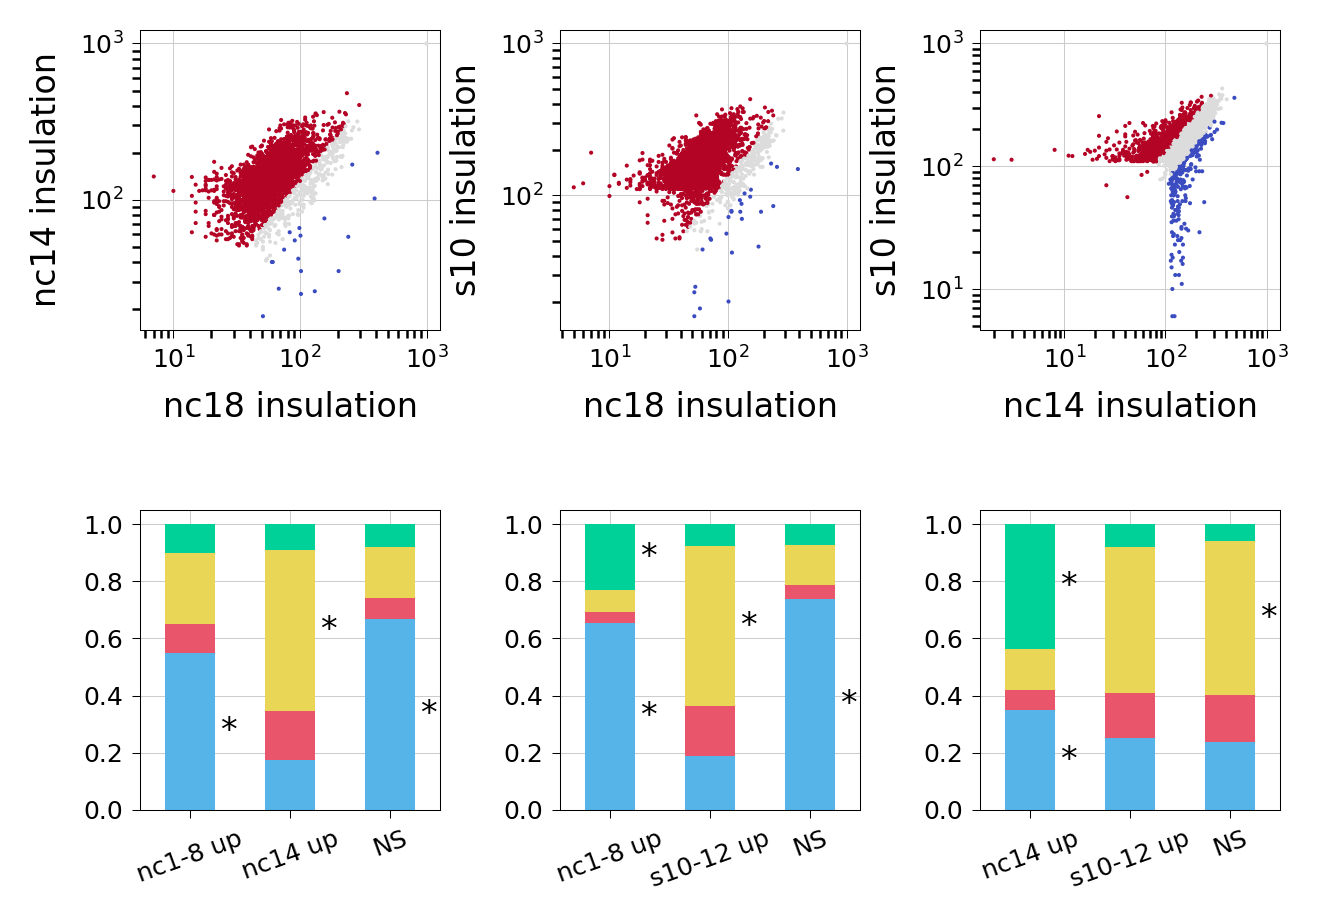

In [16]:
from config import key_to_name
fig, axs = init_subplots_exact(6, 2, fgsz=(1, 1), dpi = 150, yspace=1.6, xspace=1.4,  y_ratios=[1, 1])

for _, (key1, key2) in enumerate([['nc18', 'nc14'], ['nc18', 's10'], ['nc14', 's10']]):
    plt.sca(axs[_])
    x, y = boundaryStrengths[key1], boundaryStrengths[key2]
    idx = (x > 50) | (y > 50)
    x = x[idx]
    y = y[idx]
    
    
    c = np.zeros(len(x)).astype(int)
    c[np.log2(x/y) < -.4] = 1
    c[np.log2(x/y) > .4] = -1
    plt.scatter(x, y, s=.4, c = c, cmap='coolwarm')
    plt.xscale('log')
    plt.yscale('log')
    
    name1 = key_to_name[key1] + " up"
    name2 = key_to_name[key2] + " up"

    plt.xlabel(f"{key1} insulation")
    plt.ylabel(f"{key2} insulation")

    vals = [
        all_cses.loc[boundaryStrengths.index[idx][c > 0], 'cluster'].value_counts(normalize=True).sort_index(),
        all_cses.loc[boundaryStrengths.index[idx][c == 0], 'cluster'].value_counts(normalize=True).sort_index(),
        all_cses.loc[boundaryStrengths.index[idx][c < 0], 'cluster'].value_counts(normalize=True).sort_index(),
    ]

    sum_vals = [
        all_cses.loc[boundaryStrengths.index[idx][c > 0], 'cluster'].value_counts(normalize=False).sort_index(),
        all_cses.loc[boundaryStrengths.index[idx][c == 0], 'cluster'].value_counts(normalize=False).sort_index(),
        all_cses.loc[boundaryStrengths.index[idx][c < 0], 'cluster'].value_counts(normalize=False).sort_index(),
    ]
    baseline = all_cses.loc[boundaryStrengths.index[idx]]['cluster'].value_counts()
    ps = []
    for c, v in enumerate(sum_vals):
        name = [name2, 'NS', name1][c]
        for clust in [0, 1, 2, 3]:
            oe, p = scipy.stats.fisher_exact(
                [[v[clust], v.drop(clust).sum()],
                [baseline[clust], baseline.drop(clust).sum()]],
            )
            ps.append([name, p*np.sign(np.log2(oe)), clust])
    
    vals = pd.concat(vals, axis=1, )
    vals.columns = [name2, 'NS', name1]
    vals = vals[[name1, name2, 'NS']]

    ps = pd.DataFrame(ps, columns = ['bar_idx', 'pval', 'cluster'])
    ps_pivot = ps.pivot(index='bar_idx', columns='cluster', values='pval')
    # ps_pivot.index = vals.columns
        

    vals.T.plot.bar(stacked=True, color=cluster_to_rgb.values(), ax=axs[_ + 3], legend=False,)
    plt.sca(axs[_ + 3])
    plt.xticks(rotation = 20)


    vals = vals.T
    ps_pivot = ps_pivot.T
    size = .05
    for cu, u in enumerate(vals.index):
        for c, col in enumerate(range(4)):
            p = ps_pivot.loc[col, u]
            if (abs(p) < .05) & (p > 0):
                if c == 0:
                    base = 0
                else:
                    base = vals.loc[u].cumsum()[c-1]# - df.loc['' + u].cumsum()[0]
                y = base + vals.loc[u][col]/2
                plt.text(cu + .3, y, '*', va='center', fontsize=8, ha='left')
        d = np.abs(arr(axs[_+3].get_xlim())).sum()*size

/Genomics/argo/users/gdolsten/.conda/envs/mamba/envs/new_3dgenome/lib/python3.10/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)
/Genomics/argo/users/gdolsten/.conda/envs/mamba/envs/new_3dgenome/lib/python3.10/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


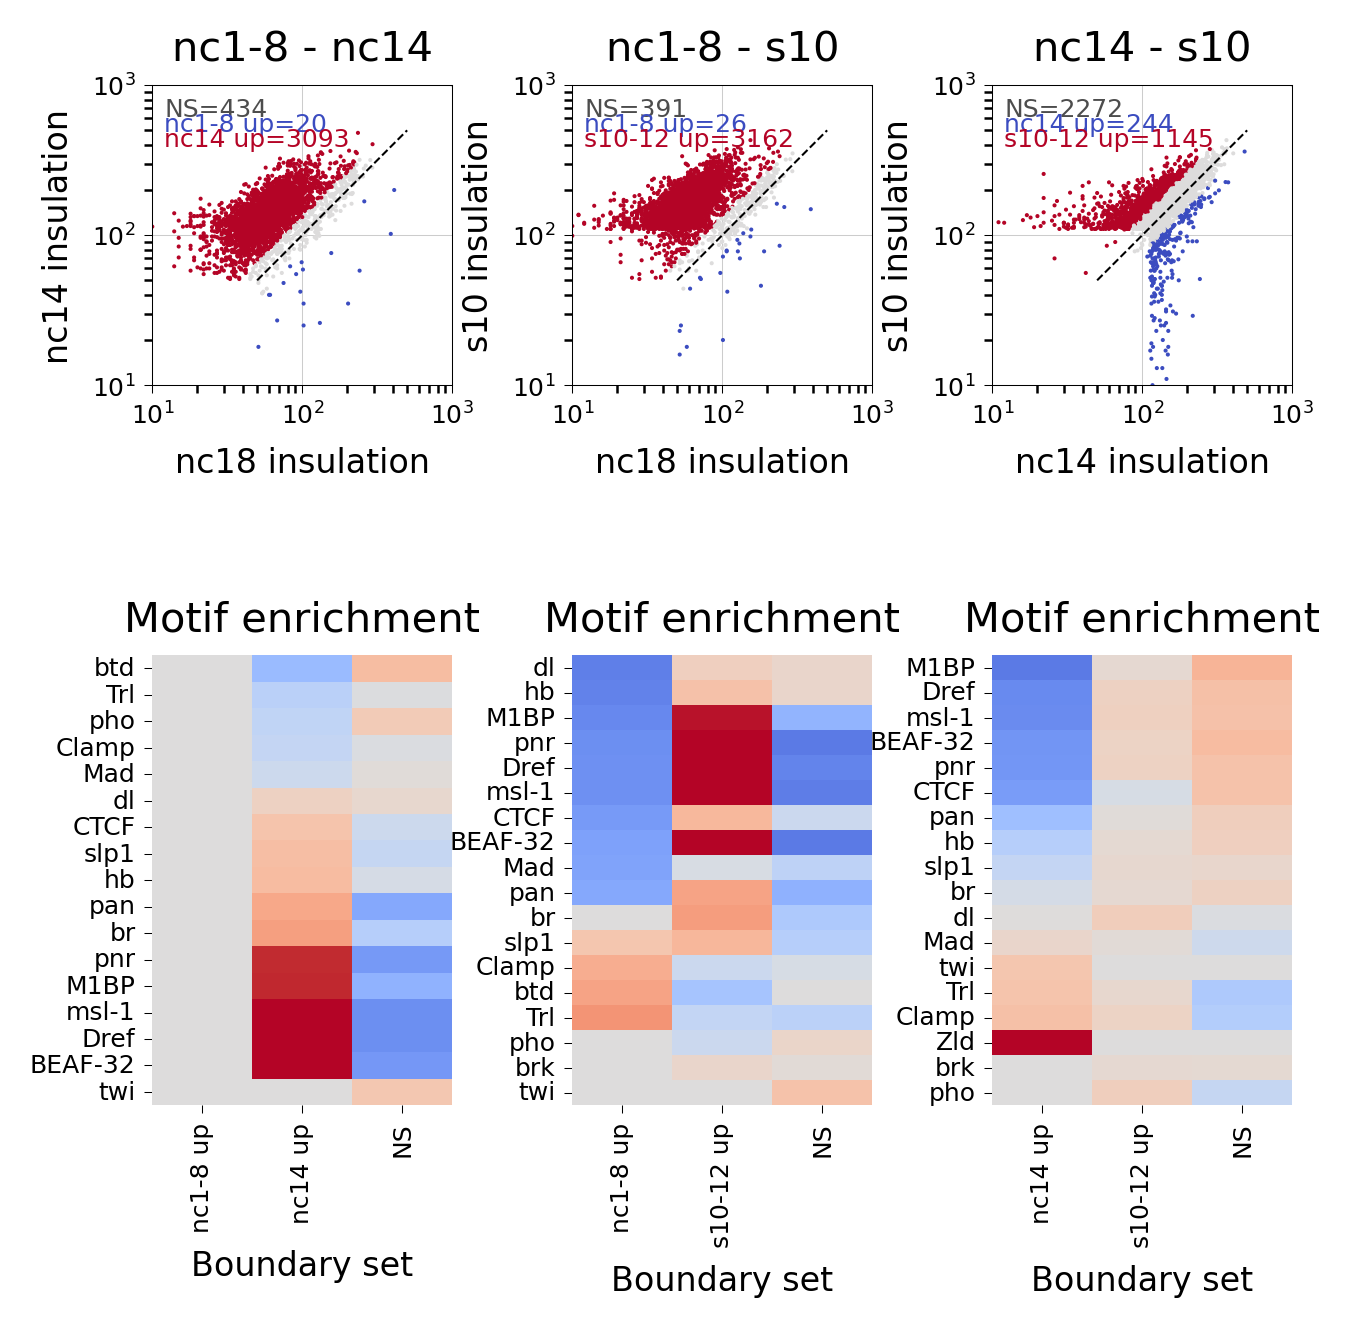

In [17]:
from config import key_to_name
fig, axs = init_subplots_exact(6, 2, fgsz=(1, 1), dpi = 150,
                              yspace=1.6, xspace=1.4, 
                              y_ratios=[1, 1.5])

files_to_pileup = {}

for _, (key1, key2) in enumerate([['nc18', 'nc14'], ['nc18', 's10'], ['nc14', 's10']]):
    plt.sca(axs[_])
    x, y = boundaryStrengths[key1], boundaryStrengths[key2]
    idx = (x > 50) | (y > 50)
    x = x[idx]
    y = y[idx]
    
    c = np.zeros(len(x)).astype(int)
    c[np.log2(x/y) < -.4] = 1
    c[np.log2(x/y) > .4] = -1
    plt.scatter(x, y, s=.4, c = c, cmap='coolwarm')
    plt.xscale('log')
    plt.yscale('log')
    
    name1 = key_to_name[key1] + " up"
    name2 = key_to_name[key2] + " up"

    plt.xlabel(f"{key1} insulation")
    plt.ylabel(f"{key2} insulation")

    z = np.linspace(50, 500)
    plt.plot(z, z, color='black', linestyle='--')
    plt.text(0.04, 1-.04, f'NS={(c==0).sum()}', transform=plt.gca().transAxes,fontsize=6, va='top', c = mod_coolwarm(0.5))
    plt.text(0.04, .95-.04, f'{name1}={(c==-1).sum()}', transform=plt.gca().transAxes,fontsize=6, va='top', c = mod_coolwarm(-1.0))
    plt.text(0.04, .9-.04, f'{name2}={(c==1).sum()}', transform=plt.gca().transAxes,fontsize=6, va='top', c = mod_coolwarm(1.0))
    plt.title(f'{key1.replace("nc18", "nc1-8")} - {key2}')
    plt.xlim([10, 1000])
    plt.ylim([10, 1000])

    
    idx1 = x.index[c == -1]
    idx2 = x.index[c == 1]
    idx_ns = x.index[c == 0]

    
    labels = [name1, name2, 'NS']
    vals = []
    files_to_pileup[(key1, key2, 'down')] = idx1
    files_to_pileup[(key1, key2, 'ns')] = idx_ns
    files_to_pileup[(key1, key2, 'up')] = idx2
    
    for _2, idx in enumerate([idx1, idx2, idx_ns]):
        if len(idx) > 20:
            fc = get_motif_fc(boundary_motifs, 
                          idx[idx.isin(boundary_motifs.index)], 
                          boundary_motifs.index[~boundary_motifs.index.isin(idx)], 
                          freq = .1
                    )
        else:
            fc = pd.Series([])
        vals.append(fc)
            
    v = pd.concat(vals, axis=1).fillna(0)
    v.columns = labels
    plt.sca(axs[_ + 3])
    v.index = v.index.str.replace("vfl", 'Zld')
    sns.heatmap(v.fillna(0), vmin = -2, vmax = 2, cmap='coolwarm', zorder=3, ax=axs[_+3],
               cbar=False, yticklabels=True)
    plt.title("Motif enrichment")
    plt.xlabel("Boundary set")

### Pileups at these boundaries

In [18]:
keys = [
('nc18', 'nc14', 'down'),
('nc18', 'nc14', 'ns'),
('nc18', 'nc14', 'up'),
('nc18', 's10', 'down'),
('nc18', 's10', 'ns'),
('nc18', 's10', 'up'),
('nc14', 's10', 'down'),
('nc14', 's10', 'ns'),
('nc14', 's10', 'up'),
]

In [19]:
for key in keys:
    files_to_pileup[key]
    break

In [20]:
cooldict = {
    'nc14_1_1+1_2+2_1+2_2' : cooler.Cooler('../cools/nc14_1_1+1_2+2_1+2_2.base_resolution=100.mcool::/resolutions/400'),
    'nc1-8_1_1+1_2+2_1+2_2' : cooler.Cooler('../cools/nc1-8_1_1+1_2+2_1+2_2.base_resolution=100.mcool::/resolutions/400'),
    's10-12_1_1+1_2+2_1+2_2' : cooler.Cooler('../cools/s10-12_1_1+1_2+2_1+2_2.base_resolution=100.mcool::/resolutions/400'),
}

In [21]:
import sys
sys.path.append('/Genomics/argo/users/gdolsten/pritlab/jupys/tregs/code/')
from apa_figures import apa_diag_nonorm

In [23]:
import cooltools
expected_dict = {}
for condition, clr in cooldict.items():    
    expected = cooltools.expected_cis(clr, nproc=32, smooth=False, )
    expected_dict[condition] = expected

2025-04-30 14:12:09 - INFO - creating a Pool of 32 workers
/Genomics/argo/users/gdolsten/.conda/envs/mamba/envs/new_3dgenome/lib/python3.10/site-packages/cooltools/api/expected.py:351: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = dict(iter(bins.groupby("chrom")[clr_weight_name]))
2025-04-30 14:17:36 - INFO - creating a Pool of 32 workers
/Genomics/argo/users/gdolsten/.conda/envs/mamba/envs/new_3dgenome/lib/python3.10/site-packages/cooltools/api/expected.py:351: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = dict(iter(bins.groupby("chrom")[clr_weight_name]))
2025-04-30 14:30:56 - INFO - creat

In [24]:
import cooltools
import bioframe

pileup_dict = defaultdict(dict)
for key in files_to_pileup:
    boundaries = files_to_pileup[key]
    boundaries = [extend_l(make_int(x.split("_")), 6000) for x in boundaries]
    boundaries = pd.DataFrame(boundaries)
    boundaries.columns = ["chrom", "start", "end"]

    for condition, clr in cooldict.items():    
        view = bioframe.make_viewframe(clr.chromsizes)    
        stack = cooltools.pileup(clr, boundaries, expected_df=expected_dict[condition], flank = 32 * clr.info['bin-size'], nproc=32)
        pileup_dict[key][condition] = stack

2025-04-30 14:36:48 - INFO - creating a Pool of 32 workers
/Genomics/argo/users/gdolsten/.conda/envs/mamba/envs/new_3dgenome/lib/python3.10/site-packages/cooltools/api/snipping.py:575: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  region1_coords[0]
/Genomics/argo/users/gdolsten/.conda/envs/mamba/envs/new_3dgenome/lib/python3.10/site-packages/cooltools/api/snipping.py:578: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  region2_coords[0]
/Genomics/argo/users/gdolsten/.conda/envs/mamba/envs/new_3dgenome/lib/python3.10/site-packages/cooltools/api/snipping.py:575: FutureWarning: Series.__getitem__ treating keys as position

/tmp/ipykernel_2986917/3986766732.py:22: RuntimeWarning: Mean of empty slice
  avg_m = np.nanmean(mats[key2], axis=0)


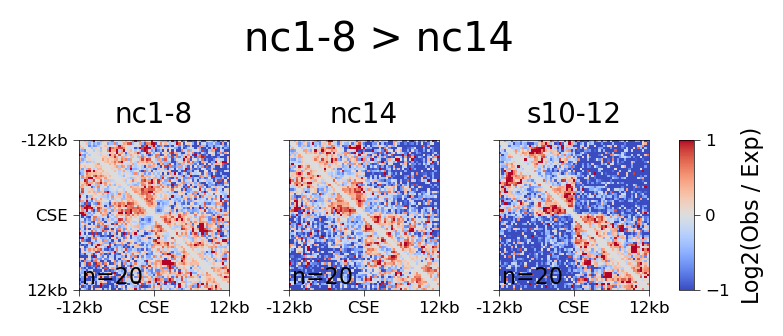

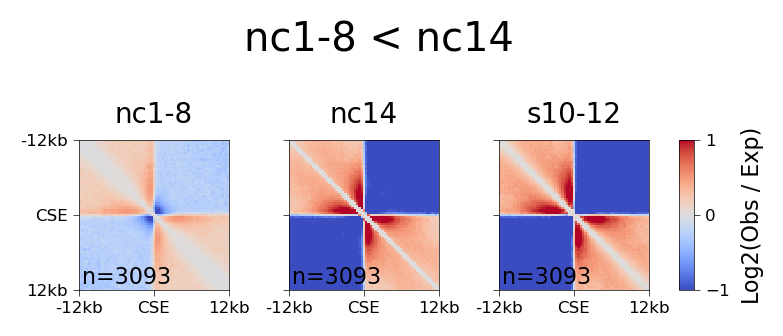

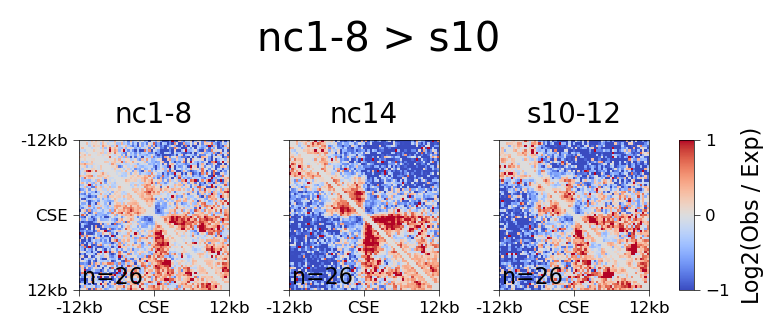

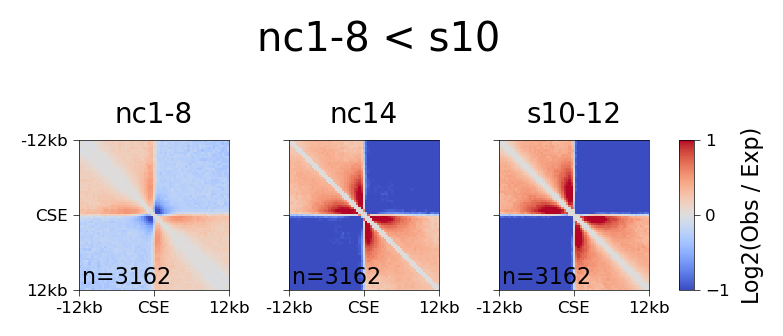

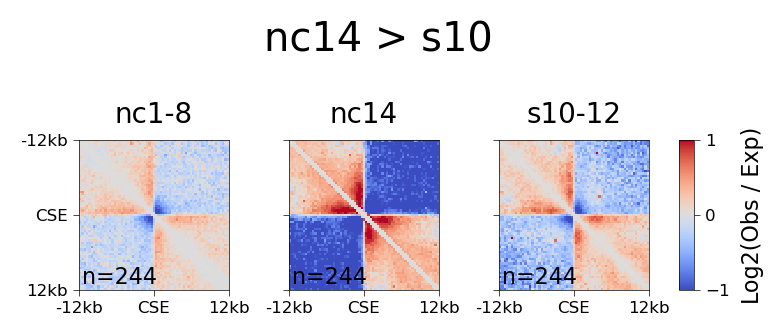

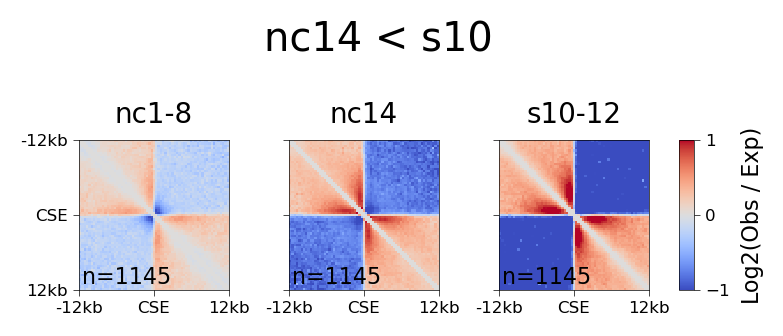

In [28]:
key2name = {
    'nc1-8_1_1+1_2+2_1+2_2' : 'nc1-8'  ,
    'nc14_1_1+1_2+2_1+2_2' : 'nc14'   ,
    's10-12_1_1+1_2+2_1+2_2' : 's10-12' ,
}

keys = ['nc1-8_1_1+1_2+2_1+2_2', 'nc14_1_1+1_2+2_1+2_2', 's10-12_1_1+1_2+2_1+2_2',]
delta = int((32*400)//1e3)
for key in pileup_dict:
    cond1, cond2, direction = key
    cond1, cond2 = cond1.replace('nc18', 'nc1-8'), cond2.replace('nc18', 'nc1-8')
    if direction == 'down':
        label = f'{cond1} > {cond2}'
    elif direction == 'up':
        label = f'{cond1} < {cond2}'
    else:
        continue
    mats = pileup_dict[key]
    fig, axs = init_subplots_exact(3, 1, fgsz=(.75, .75), dpi = 100, xspace=1.4)
    for c, key2 in enumerate(keys):
        plt.sca(axs[c])
        avg_m = np.nanmean(mats[key2], axis=0)
        obs_exp = np.log2(avg_m)
        obs_exp[np.isnan(obs_exp)] = 0
        obs_exp = obs_exp + obs_exp.T
        color = axs[c].matshow(obs_exp, cmap='coolwarm', vmin=-1, vmax=1,
                      extent=[-delta, delta, delta, -delta])
        axs[c].set_title(f'{key2name[key2]}')
        axs[c].grid(False)
        axs[c].set_xticks([-delta, 0, delta])
        axs[c].set_yticks([-delta, 0, delta])
        
        if c == 0:
            axs[c].set_yticklabels([f'{-delta}kb', 'CSE', f'{delta}kb'])
        else:
            axs[c].set_yticklabels([])
        axs[c].set_xticklabels([f'{-delta}kb', 'CSE', f'{delta}kb'])

        axs[c].tick_params(labelbottom=True, bottom=True, top=False, labeltop=False)
        if c == 2:
            newax1 = axs[c].inset_axes(transform=axs[c].transAxes, bounds = (1.2, 0, .1, 1))
            plt.colorbar(color, cax = newax1)
            newax1.set_yticks([-1, 0, 1])
            newax1.set_ylabel("Log2(Obs / Exp)") 
        plt.text(0.02, 0.04, f'n={len(mats[key2])}', transform=axs[c].transAxes, fontsize=8)
    # fig.savefig(f'./new_figures/s1/{"_".join(key)}.pdf', bbox_inches = 'tight')
    fig.suptitle(label, y = 4.2, x=2)